# 16S Analyses of the Longitudinal Acne Study
## Relative Abundance and Alpha Diversity Plots

Date created: 10/15/2024

Notebook authors: Yang Chen and Britta De Pessemier

Data analysis by: Tyler Myers, Britta De Pessemier, and Yang Chen

This notebook plots the following:

- 16S V1-V3 and V4 relative abundance plots at Genus taxon level
- 16S V1-V3 and V4 Shannon alpha diversity plots at Genus taxon level
- 16S V1-V3 and V4 Faith PD alpha diversity plots at Genus taxon level

In [4]:
# Import Python packages
import pandas as pd
import numpy as np
import biom
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle
import os
from matplotlib.colors import ListedColormap
from matplotlib.colors import to_rgba


In [5]:
# Define the taxa level
taxa_level = 'Genus'

In [6]:
# Load the metadata
metadata_path = '../Metadata/metadata_final_22102024.tsv'
metadata = pd.read_csv(metadata_path, sep='\t')
metadata['severity_group'].value_counts()

severity_group
low Acne_L         70
moderate Acne_L    64
absent Healthy     57
absent Acne_NL     27
high Acne_L        25
low Acne_NL        23
Name: count, dtype: int64

In [7]:
# Define paths to the collapsed taxa tables
biom_paths = {
    'V1-V3': f'../Data/16S/Tables/16S_V1-V3_{taxa_level}_collapsed.biom',
    'V4': f'../Data/16S/Tables/16S_V4_{taxa_level}_collapsed.biom'
}

In [8]:
# Predefined color palette for specific families
if taxa_level == "Family":
    taxa_colors = {
        ' f__Propionibacteriaceae': '#ffa505',  # Bright orange
        ' f__Mycobacteriaceae': '#70a8dc',      # Blue
        ' f__Streptococcaceae': '#92f0f0',      # Fluorescent light blue
        ' f__Porphyromonodaceae': '#e2b46c',    # Beige
        ' f__Bacteroidaceae': '#ffe59a',        # Pastel yellow
        ' f__Neisseriaceae': '#f6475f',         # Pinkish
        ' f__Moraxellaceae': '#c5bce0',         # Pastel purplish
        ' f__Marinomonadaceae': '#f4cccd',  # Light pink
        ' f__Celerinatantimonadaceae': '#bcbcbc',  # Light gray
        ' f__Alteromonadaceae': '#daead3',  # Pale mint green
        'Others': '#ededed'                 # White
    }
elif taxa_level == "Genus":
    taxa_colors = {
        ' g__Cutibacterium': '#ffa505',  # Bright orange
        # ' g__uncultured': '#808080',      # Grey
        ' g__uncultured Neisseriaceae': '#f6475f',         # Pinkish
        ' g__Staphylococcus': '#92f0f0',      # Fluorescent light blue
        ' g__Streptococcus': '#e2b46c',    # Beige
        ' g__Corynebacterium': '#ffe59a',        # Pastel yellow
        ' g__Lawsonella': '#70a8dc',         # Light blue
        ' g__Veillonella': '#c5bce0',         # Pastel purplish
        ' g__Micrococcus':'#f4cccd',           # Pastel yellow
        ' g__Alloprevotella': '#bcbcbc',        # Light gray
        ' g__Lactobacillus': '#daead3',     # Pale mint green
        ' g__Neisseria': '#f6475f',         # Redish pink
        'Others': '#ededed'                 # White
    }

In [9]:
# A list of unique colors to use for taxa not predefined
unique_colors = sns.color_palette("deep", n_colors=20).as_hex()
unique_color_iter = cycle(unique_colors)  # Iterator to cycle through unique colors

In [10]:
# Function to load BIOM table, collapse by taxa, sort rows by row sum, remove specified samples, and convert to relative abundance
def load_biom_table(biom_path, metadata_path):
    # Load metadata as a DataFrame from the file path
    metadata = pd.read_csv(metadata_path, sep='\t')

    # Load BIOM table and convert to a DataFrame
    table = biom.load_table(biom_path)
    df = pd.DataFrame(table.matrix_data.toarray(),
                      index=table.ids(axis='observation'),
                      columns=table.ids(axis='sample'))
    
    # Replace 'uncultured' row with 'uncultured Neisseriaceae'
    df = df.rename(index={' g__uncultured': ' g__uncultured Neisseriaceae'})
    
    # Sort rows by row sum in descending order
    df['row_sum'] = df.sum(axis=1)
    df = df.sort_values(by='row_sum', ascending=False)
    
    # Drop the 'row_sum' column before proceeding
    df = df.drop(columns=['row_sum'])
    
    # Convert the table to relative abundances
    df = df.div(df.sum(axis=0), axis=1)
    
    return df


In [11]:
# Function to determine the top 15 families and collapse the rest as "Others"
def collapse_top_15(df):
    top_families = df.sum(axis=1).nlargest(15).index  # Select top 15 families
    df_top = df.loc[top_families]
    df_top.loc['Others'] = df.loc[~df.index.isin(top_families)].sum()
    return df_top

In [12]:
# Function to get or assign colors to families
def get_taxa_colors(families, global_taxa_color_map):
    for taxa in families:
        if taxa not in global_taxa_color_map:
            if taxa in taxa_colors:
                global_taxa_color_map[taxa] = taxa_colors[taxa]
            else:
                global_taxa_color_map[taxa] = next(unique_color_iter)  # Assign a new unique color
    return global_taxa_color_map

## Relative abundance plots

In [13]:
def plot_relative_abundance(df, metadata, group_column, output_dir, key, taxa_color_map):
    # Average by group
    df_grouped = df.groupby(metadata[group_column], axis=1).mean()

    # Reorder the columns to Healthy, Acne Non-lesional, and Acne Lesional Low, Mod, High severity
    desired_order = ['Healthy', 'Acne_NL', 'Acne_L']

    df_grouped = df_grouped[desired_order]
    
    # Create output file paths
    output_png_file = os.path.join(output_dir, f'{key}_{taxa_level}_relative_abundance_plot.png')  # Save as png
    output_svg_file = os.path.join(output_dir, f'{key}_{taxa_level}_relative_abundance_plot.svg')  # Save as svg
    
    # Set plot title based on key
    if key == 'V1-V3':
        plot_title = f'16S rRNA (V1-V3) Relative Abundance'
    elif key == 'V4':
        plot_title = f'16S rRNA (V4) Relative Abundance'
    else:
        plot_title = f'16S rRNA (V4) Relative Abundance'

    # Plot
    ax = df_grouped.T.plot(kind='bar', stacked=True, figsize=(10, 10),
                           width=0.8,  # Bars closer together
                           color=[taxa_color_map.get(fam, '#ADD8E6') for fam in df_grouped.index])

    plt.ylabel('Relative Abundance', fontsize=18)
    plt.xlabel(' ')
    plt.title(plot_title, fontsize=20)

    # Set x-axis labels and sample size retained after rarefaction for V1-V3 and V4
    if key == 'V1-V3':
        new_labels = ['Healthy\nSkin\n(n=47)', 'Acne\nNon-lesional\n(n=47)', 'Acne\nLesional\n(n=142)']
    elif key == 'V4':
        new_labels = ['Healthy\nSkin\n(n=27)', 'Acne\nNon-lesional\n(n=45)', 'Acne\nLesional\n(n=145)']

    # Set the new tick labels
    plt.xticks(ticks=range(len(new_labels)), labels=new_labels, rotation=0, ha='center', fontsize=18)
    plt.yticks(fontsize=18)
    
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=16, title=taxa_level, title_fontsize=18)
    plt.tight_layout()

    plt.savefig(output_png_file, format='png', dpi=600)  # Save as png
    plt.savefig(output_svg_file, format='svg')  # Save as svg
    plt.show()

    plt.close()


/var/folders/22/yck9vwx53w1c38tvj_c0_tz00000gn/T/ipykernel_82231/1648291295.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_grouped = df.groupby(metadata[group_column], axis=1).mean()


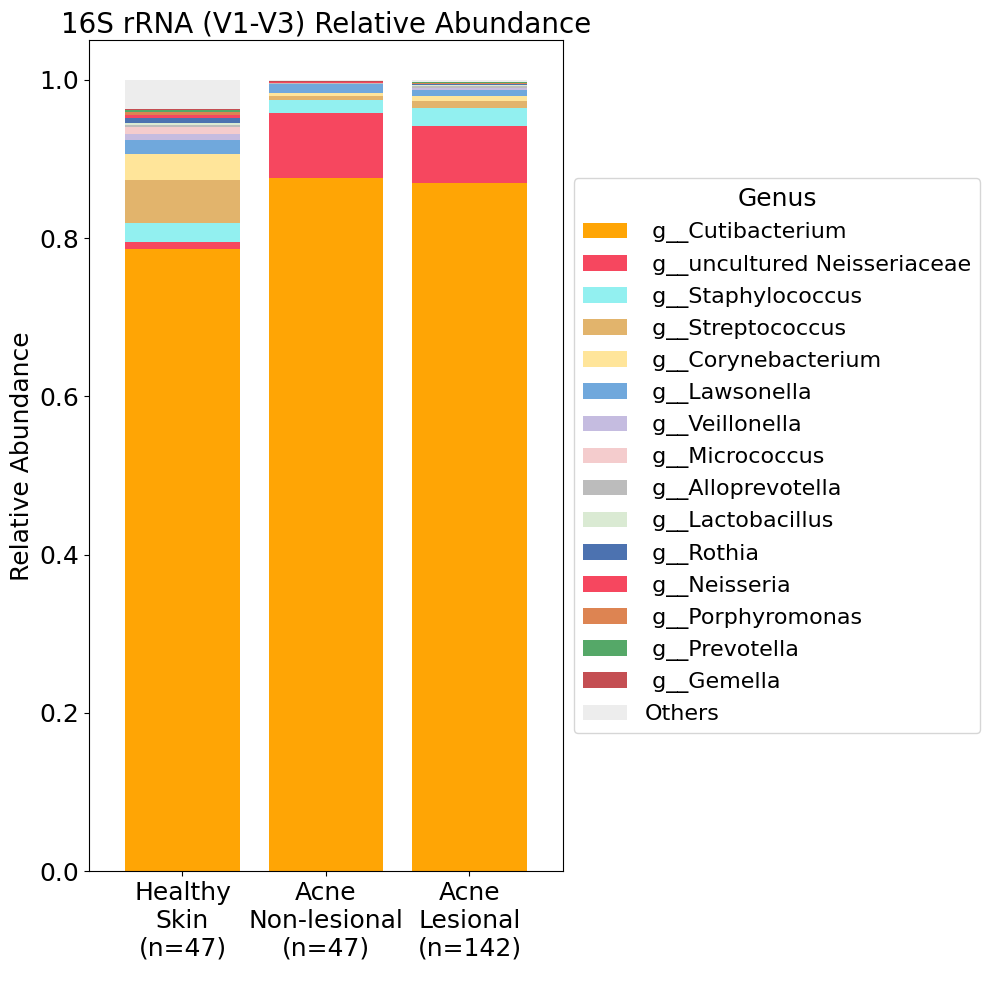

/var/folders/22/yck9vwx53w1c38tvj_c0_tz00000gn/T/ipykernel_82231/1648291295.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_grouped = df.groupby(metadata[group_column], axis=1).mean()


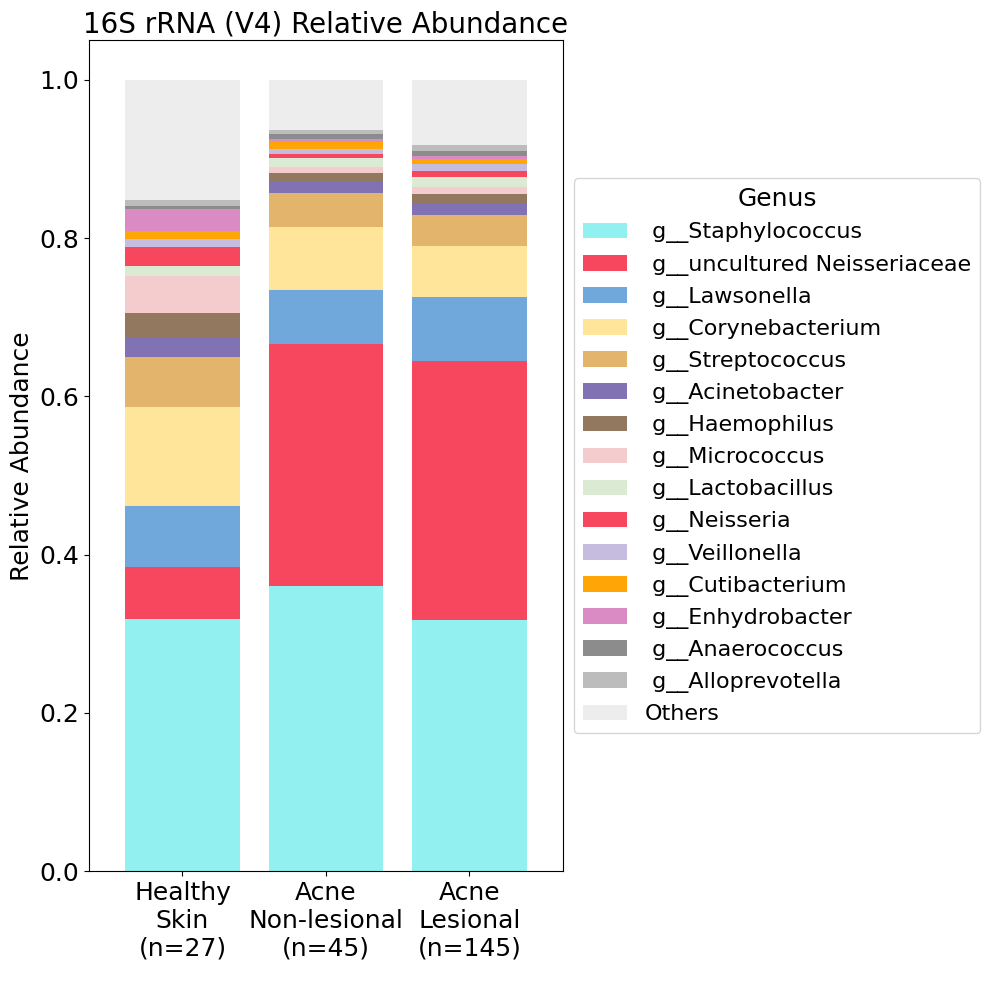

In [14]:
# Process both BIOM files
global_taxa_color_map = {}  # Store colors assigned to families across both datasets
for key, biom_path in biom_paths.items():
    # Load and process the BIOM table
    df = load_biom_table(biom_path, metadata_path)
    df_top_15 = collapse_top_15(df)  # Now using the top 15 function
    
    # Define the output directory for the current key
    output_dir = '../Figures/16S_Figures/relative_abundance/'
    os.makedirs(output_dir, exist_ok=True)  # Ensure the output directory exists
    
    # Merge with metadata
    metadata_subset = metadata.set_index('SampleID').loc[df.columns]  # Assuming SampleID in metadata matches samples in BIOM table
    
    # Generate or retrieve colors for the top families in this dataset
    global_taxa_color_map = get_taxa_colors(df_top_15.index, global_taxa_color_map)
    
    # Plot the results and save in the respective folder 
    plot_relative_abundance(df_top_15, metadata_subset, 'group', output_dir, key, global_taxa_color_map)

## Shannon alpha diversity plots

In [15]:
# Additional Python packages for alpha diversity analyses
from skbio.diversity import alpha_diversity
from scipy.stats import mannwhitneyu

In [16]:
def darken_color(color, amount=0.3):
    """
    Darken a given color by a certain amount.
    
    Parameters:
    - color: The base color (as a hex string or color name).
    - amount: The amount to darken the color by (default: 0.3).
    
    Returns:
    - A darkened color as a hex string.
    """
    c = to_rgba(color)
    return (c[0] * (1 - amount), c[1] * (1 - amount), c[2] * (1 - amount), c[3])

In [17]:
def calculate_shannon_alpha_diversity_and_plot(biom_path, metadata_path, group_col, title_suffix):
    # Load metadata as a DataFrame from the file path
    metadata = pd.read_csv(metadata_path, sep='\t')
    metadata = metadata.set_index('SampleID')
    
    # Load biom table
    feature_table = load_biom_table(biom_path, metadata_path)

    # Transpose feature_table so rows are sample IDs
    feature_table = feature_table.transpose()

    # Calculate Shannon diversity
    shannon_values = alpha_diversity('shannon', feature_table.values, ids=feature_table.index)
    
    # Merge Shannon values with metadata
    common_samples = metadata.index.intersection(feature_table.index)
    metadata = metadata.loc[common_samples].copy()
    metadata['Shannon'] = shannon_values.loc[common_samples]
    
    # Set the custom order for the groups: Healthy first, then Acne Non-lesional, then Acne Lesional
    desired_order = ['Healthy', 'Acne_NL', 'Acne_L']

    # Set the color palette for the groups in the correct order
    palette = {
        'Healthy': '#3333B3',     # Dark Blue color for Healthy
        'Acne_NL': '#5cbccb',     # Blue color for Acne Non-Lesional
        'Acne_L': '#f16c52'       # Red color for Acne Lesional
    }

    # Create a new column for severity category based on local lesion severity
    metadata['severity_category'] = pd.cut(metadata['local_lesion_severity'],
                                        bins=[0, 2, 4, 6],  # Low (1-2), Moderate (3-4), High (5-6)
                                        labels=['low', 'moderate', 'high'])

    # Define a custom palette for severity categories within Acne_L group
    severity_palette = {
        'low': '#F1948A',      # Light red for low severity
        'moderate': '#EC7063',  # Red for moderate severity
        'high': '#C0392B'       # Dark red for high severity
    }

    # Create plot size
    plt.figure(figsize=(5.5, 10))

    # Plot the Shannon diversity across the groups using a boxplot with custom colors and order
    ax = sns.boxplot(x=group_col, y='Shannon', data=metadata, palette=palette, order=desired_order)

    # Darken the colors for the strip plot manually
    darker_palette = {key: darken_color(color) for key, color in palette.items()}

    # Plot the general stripplot with darkened colors
    sns.stripplot(x=group_col, y='Shannon', data=metadata, palette=darker_palette, jitter=True, dodge=False, ax=ax, linewidth=0.6, order=desired_order)

    # Add a second stripplot specifically for Acne_L, coloring by severity
    sns.stripplot(x=metadata[metadata[group_col] == 'Acne_L'][group_col], 
                  y=metadata[metadata[group_col] == 'Acne_L']['Shannon'], 
                  hue=metadata[metadata[group_col] == 'Acne_L']['severity_category'],
                  palette=severity_palette, jitter=True, dodge=False, ax=ax, linewidth=0.6)

    # Adjust the legend for the severity categories
    handles, labels = ax.get_legend_handles_labels()
    severity_handles = handles[-3:]  # Get the last three handles, which correspond to severity levels
    severity_labels = ['Low (1-2)', 'Moderate (3-4)', 'High (5-6)']  # Rename the labels

    # Move the legend outside the boxplot to the right
    ax.legend(severity_handles, severity_labels, title='Lesional Severity Score', 
            loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, frameon=True, title_fontsize=16, fontsize=14)

    # Add the title and labels
    plt.title(f'16S rRNA ({title_suffix}) Alpha Diversity', fontsize=20)
    plt.xlabel(' ')
    plt.ylabel('Shannon Index', fontsize=18)

    # Set x-axis labels and sample size retained after rarefaction for V1-V3 and V4
    if key == 'V1-V3':
        new_labels = ['Healthy\nSkin\n(n=47)', 'Acne\nNon-lesional\n(n=47)', 'Acne\nLesional\n(n=142)']
    elif key == 'V4':
        new_labels = ['Healthy\nSkin\n(n=27)', 'Acne\nNon-lesional\n(n=45)', 'Acne\nLesional\n(n=145)']

    # Set tick labels    
    plt.xticks(ticks=range(len(new_labels)), labels=new_labels, rotation=0, ha='center', fontsize=18)
    plt.yticks(fontsize=18)

    # Pairwise significance testing using Mann-Whitney U test
    groups = ['Healthy', 'Acne_NL', 'Acne_L']
    p_values = {}
    
    # Heights to draw the annotation lines
    y_max = max(metadata['Shannon']) + 0.1
    height_step = 0.15  # Height step between lines
    
    # Perform pairwise comparisons
    for i, group1 in enumerate(groups):
        for j, group2 in enumerate(groups):
            if i < j:
                # Get the Shannon values for each group
                group1_values = metadata[metadata[group_col] == group1]['Shannon']
                group2_values = metadata[metadata[group_col] == group2]['Shannon']
                
                # Perform Mann-Whitney U test
                stat, p = mannwhitneyu(group1_values, group2_values, alternative='two-sided')
                p_values[f'{group1} vs {group2}'] = p
                
                # Determine the significance label based on p-value thresholds
                if p >= 0.05:
                    label = f"{p:.2e}"
                elif p < 0.001:
                    label = '***  ' + f"{p:.2e}"
                elif p < 0.01:
                    label = '**  ' + f"{p:.2e}"
                else:
                    label = '*  ' + f"{p:.2e}"
                
                # Get x coordinates of the boxplots
                x1, x2 = i, j
                y = y_max + height_step  # Vertical position for the horizontal line
                
                # Draw horizontal line and annotate the significance label
                plt.plot([x1, x1, x2, x2], [y, y + 0.01, y + 0.01, y], lw=1, color='black')
                plt.text((x1 + x2) * 0.5, y + 0.02, label, ha='center', va='bottom', fontsize=16)
                
                # Update y_max for the next comparison
                y_max += height_step + 0.05

        # Save the figure
        plt.savefig(f'../Figures/16S_Figures/alpha_diversity/{key}_{taxa_level}_Shannon_alpha-diversity.png', dpi=600, bbox_inches='tight', pad_inches=0.1)  # Save as png
        plt.savefig(f'../Figures/16S_Figures/alpha_diversity/{key}_{taxa_level}_Shannon_alpha-diversity.svg')  # Save as svg

    # Print pairwise p-values in scientific notation
    print("Pairwise Mann-Whitney U test p-values:")
    for comparison, p_value in p_values.items():
        print(f"{comparison}: p-value = {p_value:.2e}")


/var/folders/22/yck9vwx53w1c38tvj_c0_tz00000gn/T/ipykernel_82231/3474993845.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=group_col, y='Shannon', data=metadata, palette=palette, order=desired_order)
/var/folders/22/yck9vwx53w1c38tvj_c0_tz00000gn/T/ipykernel_82231/3474993845.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x=group_col, y='Shannon', data=metadata, palette=darker_palette, jitter=True, dodge=False, ax=ax, linewidth=0.6, order=desired_order)


Pairwise Mann-Whitney U test p-values:
Healthy vs Acne_NL: p-value = 1.82e-04
Healthy vs Acne_L: p-value = 2.09e-04
Acne_NL vs Acne_L: p-value = 8.58e-02


/var/folders/22/yck9vwx53w1c38tvj_c0_tz00000gn/T/ipykernel_82231/3474993845.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=group_col, y='Shannon', data=metadata, palette=palette, order=desired_order)
/var/folders/22/yck9vwx53w1c38tvj_c0_tz00000gn/T/ipykernel_82231/3474993845.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x=group_col, y='Shannon', data=metadata, palette=darker_palette, jitter=True, dodge=False, ax=ax, linewidth=0.6, order=desired_order)


Pairwise Mann-Whitney U test p-values:
Healthy vs Acne_NL: p-value = 5.71e-05
Healthy vs Acne_L: p-value = 6.04e-06
Acne_NL vs Acne_L: p-value = 6.73e-01


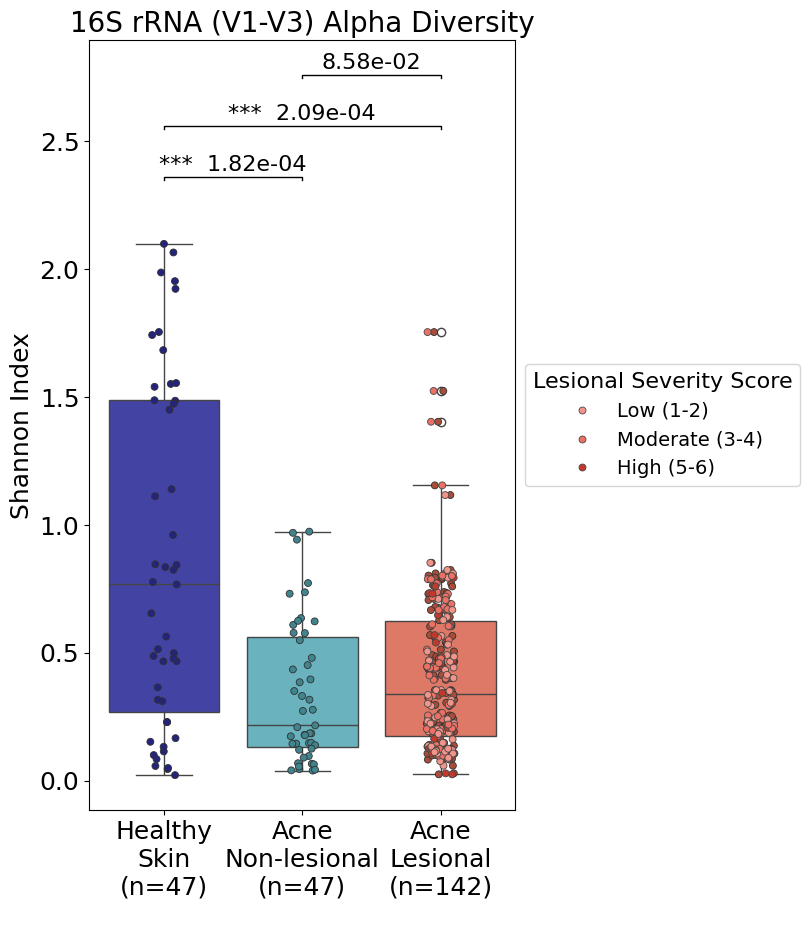

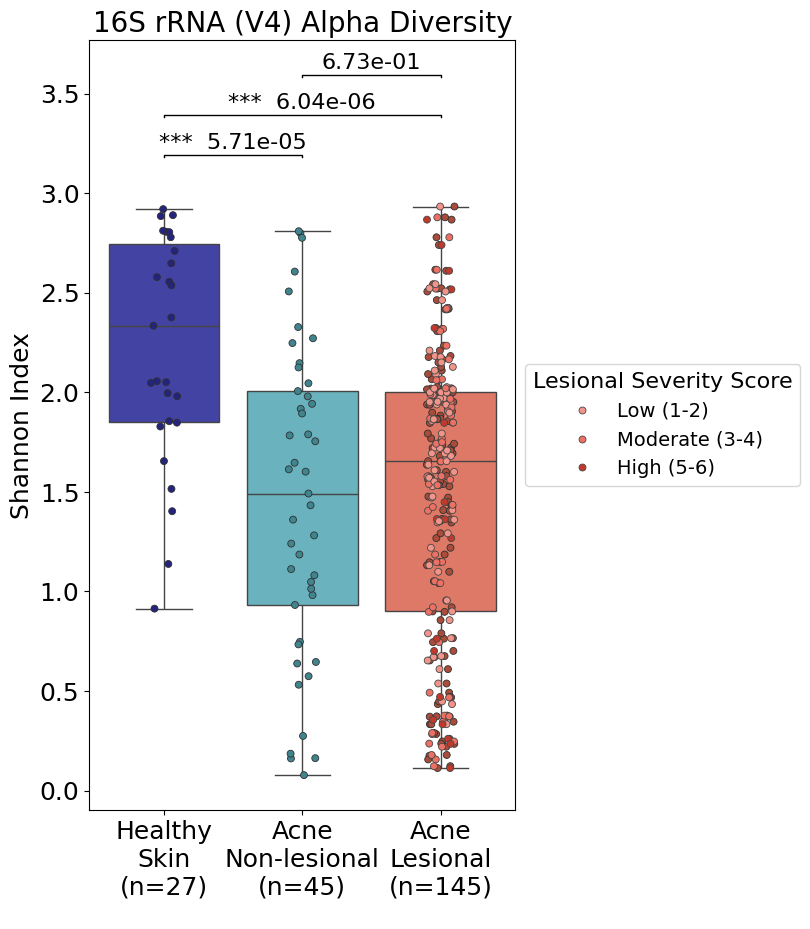

In [18]:
# Plot Alpha Diversity plots for both V1-V3 and V4
for key, biom_path in biom_paths.items():
    calculate_shannon_alpha_diversity_and_plot(
        biom_path=biom_path,
        metadata_path=metadata_path,
        group_col='group',
        title_suffix='V1-V3' if key == 'V1-V3' else 'V4'
    )


## Faith Phylogenetic Diversity alpha diversity plots

In [19]:
# Define paths to the collapsed taxa tables
biom_paths = {
    'V1-V3': f'../Data/16S/Tables/16S_V1-V3_{taxa_level}_collapsed.biom',
    'V4': f'../Data/16S/Tables/16S_V4_{taxa_level}_collapsed.biom'
}

In [20]:
def preprocess_FPD_result(FPD_result_path, key):
    # Read in Faith PD result from Xebec output
    df = pd.read_csv(FPD_result_path, sep='\t')

    # Set 'Unnamed: 0' as the index and rename column 0 to 'Faith_PD'
    df.set_index('Unnamed: 0', inplace=True)
    df.rename(columns={'0': 'Faith_PD'}, inplace=True)

    # Display the modified DataFrame without the index name
    df.index.name = None

    # Filter the DataFrame to keep only rows where the index starts with '14901.LAMI.'
    df = df[df.index.str.startswith('14901.LAMI.')]

    # Strip the '14901.' prefix from each index
    df.index = df.index.str.replace('^14901\.', '', regex=True)

    # Filter the samples based on samples retained after rarefaction used for Shannon calculation
    if key == 'V1-V3':
        # Load and process the BIOM table
        biom_df = load_biom_table(biom_paths['V1-V3'], metadata_path)
    elif key == 'V4':
        # Load and process the BIOM table
        biom_df = load_biom_table(biom_paths['V4'], metadata_path)    
    
    # Filter rows in df based on columns in biom_df
    df = df[df.index.isin(biom_df.columns)]
    
    return df

<>:16: SyntaxWarning: invalid escape sequence '\.'
<>:16: SyntaxWarning: invalid escape sequence '\.'
/var/folders/22/yck9vwx53w1c38tvj_c0_tz00000gn/T/ipykernel_82231/3117856958.py:16: SyntaxWarning: invalid escape sequence '\.'
  df.index = df.index.str.replace('^14901\.', '', regex=True)


In [27]:
def plot_faithPD_alpha_diversity(df, metadata_path, group_col, title_suffix):
    # Load metadata and set index
    metadata = pd.read_csv(metadata_path, sep='\t')
    metadata = metadata.set_index('SampleID')
    
    # Ensure we only keep samples present in both metadata and the df
    common_samples = metadata.index.intersection(df.index)
    metadata = metadata.loc[common_samples].copy()
    df = df.loc[common_samples]

    # Merge Faith_PD values with metadata
    metadata['Faith_PD'] = df['Faith_PD']
    
    # Define groups and colors
    desired_order = ['Healthy', 'Acne_NL', 'Acne_L']
    palette = {
        'Healthy': '#3333B3',     
        'Acne_NL': '#5cbccb',     
        'Acne_L': '#f16c52'       
    }
    severity_palette = {
        'low': '#F1948A',      
        'moderate': '#EC7063',  
        'high': '#C0392B'       
    }

    # Add severity category based on local lesion severity
    metadata['severity_category'] = pd.cut(
        metadata['local_lesion_severity'], bins=[0, 2, 4, 6], 
        labels=['low', 'moderate', 'high']
    )

    plt.figure(figsize=(5.5, 10))
    
    # Boxplot of Faith_PD with custom colors
    ax = sns.boxplot(x=group_col, y='Faith_PD', data=metadata, hue=group_col, palette=palette, order=desired_order)

    # Darker colors for strip plot overlay
    darker_palette = {key: color for key, color in palette.items()}
    sns.stripplot(x=group_col, y='Faith_PD', data=metadata, hue=group_col, palette=darker_palette, jitter=True, dodge=False, ax=ax, linewidth=0.6, order=desired_order)

    # Overlay severity-specific strip plot for 'Acne_L'
    sns.stripplot(
        x=metadata[metadata[group_col] == 'Acne_L'][group_col], 
        y=metadata[metadata[group_col] == 'Acne_L']['Faith_PD'], 
        hue=metadata[metadata[group_col] == 'Acne_L']['severity_category'],
        palette=severity_palette, jitter=True, dodge=False, ax=ax, linewidth=0.6
    )

    # Adjust legend for severity categories
    handles, labels = ax.get_legend_handles_labels()
    severity_handles = handles[-3:]
    severity_labels = ['Low (1-2)', 'Moderate (3-4)', 'High (5-6)']
    ax.legend(severity_handles, severity_labels, title='Lesional Severity Score', 
              loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, frameon=True, title_fontsize=16, fontsize=14)
    
    # Titles and labels
    plt.title(f'16S rRNA ({title_suffix}) Alpha Diversity', fontsize=20)
    plt.xlabel(' ')
    plt.ylabel('Faith PD', fontsize=18)

    # Set tick labels
    if key == 'V1-V3':
        new_labels = ['Healthy\nSkin\n(n=47)', 'Acne\nNon-lesional\n(n=47)', 'Acne\nLesional\n(n=142)']
    elif key == 'V4':
        new_labels = ['Healthy\nSkin\n(n=27)', 'Acne\nNon-lesional\n(n=45)', 'Acne\nLesional\n(n=145)']
    
    plt.xticks(ticks=range(len(new_labels)), labels=new_labels, rotation=0, ha='center', fontsize=18)
    plt.yticks(fontsize=18)

    plt.yticks(fontsize=18)
    
    # Set custom x-axis tick labels and font size
    if title_suffix == 'V1-V3':
        new_labels = ['Healthy\nSkin\n(n=47)', 'Acne\nNon-lesional\n(n=47)', 'Acne\nLesional\n(n=142)']
    elif title_suffix == 'V4':
        new_labels = ['Healthy\nSkin\n(n=27)', 'Acne\nNon-lesional\n(n=45)', 'Acne\nLesional\n(n=145)']


    # Significance testing (Mann-Whitney U)
    groups = ['Healthy', 'Acne_NL', 'Acne_L']
    p_values = {}
    y_max = max(metadata['Faith_PD']) + 0.1
    height_step = 0.15

    # Set a larger height step for more spacing between lines
    height_step = 2.0  # Adjust this value to control the spacing between lines

    # Loop through each pair of groups for the Mann-Whitney U test
    for i, group1 in enumerate(groups):
        for j, group2 in enumerate(groups):
            if i < j:
                # Get values for the groups being compared
                group1_values = metadata[metadata[group_col] == group1]['Faith_PD']
                group2_values = metadata[metadata[group_col] == group2]['Faith_PD']
                
                # Perform Mann-Whitney U test
                stat, p = mannwhitneyu(group1_values, group2_values, alternative='two-sided')
                p_values[f'{group1} vs {group2}'] = p
                
                # Determine the significance label based on p-value thresholds
                if p >= 0.05:
                    label = f"{p:.2e}"  # Show p-value if not significant
                elif p < 0.001:
                    label = '***  ' + f"{p:.2e}"
                elif p < 0.01:
                    label = '**  ' + f"{p:.2e}"
                else:
                    label = '*  ' + f"{p:.2e}"
                
                # Get x coordinates of the boxplots
                x1, x2 = i, j
                y = y_max + height_step  # Vertical position for the horizontal line
                
                # Draw horizontal line and annotate the significance label
                plt.plot([x1, x1, x2, x2], [y, y + 0.01, y + 0.01, y], lw=1, color='black')
                plt.text((x1 + x2) * 0.5, y + 0.04, label, ha='center', va='bottom', fontsize=14)

                # Add downward ticks at each end of the line
                tick_length = 0.05  # Adjust tick length as desired
                plt.plot([x1, x1], [y, y - tick_length], lw=1, color='black')  # Left tick
                plt.plot([x2, x2], [y, y - tick_length], lw=1, color='black')  # Right tick
                
                # Update y_max for the next comparison
                y_max += height_step + 0.1  # Adjust spacing for the next comparison

    # Save the figure
    plt.savefig(f'../Figures/16S_Figures/alpha_diversity/{key}_{taxa_level}_FaithPD_alpha-diversity.png', dpi=600, bbox_inches='tight', pad_inches=0.1)  # Save as png
    plt.savefig(f'../Figures/16S_Figures/alpha_diversity/{key}_{taxa_level}_FaithPD_alpha-diversity.svg')  # Save as svg

    plt.show()

    # Print pairwise p-values
    print("Pairwise Mann-Whitney U test p-values:")
    for comparison, p_value in p_values.items():
        print(f"{comparison}: p-value = {p_value:.2e}")

In [28]:
# Set key and paths to Faith PD results outputs from Xebec
FPD_paths = {
    'V1-V3': '../Data/16S/Faith-PD_Results/V1-V3/results/alpha_div/phylo/faith_pd/vector.tsv',
    'V4': '../Data/16S/Faith-PD_Results/V4/results/alpha_div/phylo/faith_pd/vector.tsv'
}

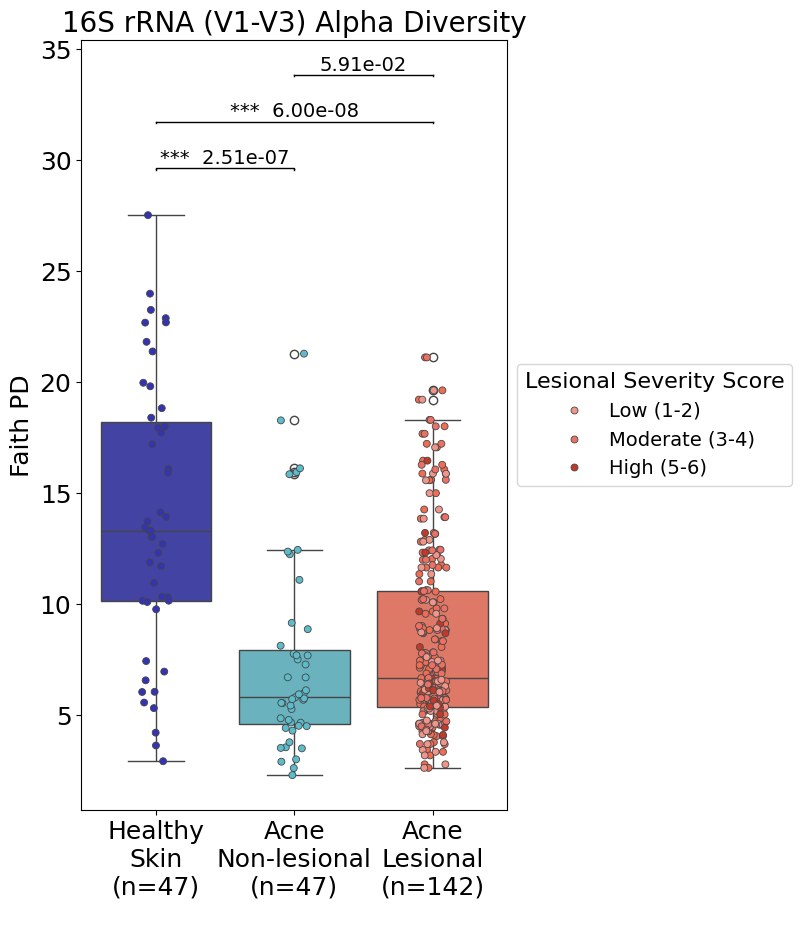

Pairwise Mann-Whitney U test p-values:
Healthy vs Acne_NL: p-value = 2.51e-07
Healthy vs Acne_L: p-value = 6.00e-08
Acne_NL vs Acne_L: p-value = 5.91e-02


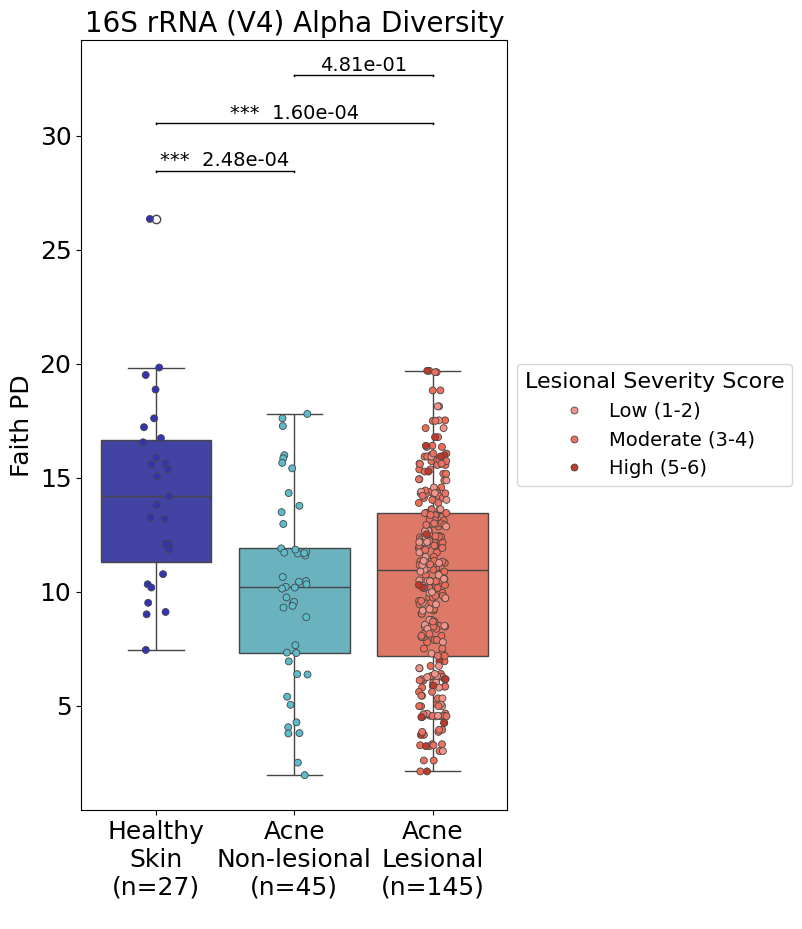

Pairwise Mann-Whitney U test p-values:
Healthy vs Acne_NL: p-value = 2.48e-04
Healthy vs Acne_L: p-value = 1.60e-04
Acne_NL vs Acne_L: p-value = 4.81e-01


In [29]:
# Plot Alpha Diversity plots for both V1-V3 and V4
for key, FPD_path in FPD_paths.items():
    plot_faithPD_alpha_diversity(preprocess_FPD_result(FPD_path, key), metadata_path, 'group', key)